In [5]:
!pip install -q datasets huggingface_hub
from huggingface_hub import login
login()  # paste your HF token when it prompts you

In [6]:
from huggingface_hub import hf_hub_download
import pandas as pd
import zipfile
import os

# 1. Download the parquet (text/metadata) file directly
parquet_path = hf_hub_download(
    repo_id="AyanHUssain00/satquery-subset",
    filename="usable_text_subset.parquet",
    repo_type="dataset"
)

# 2. Load it with pandas so we can see the actual columns
df = pd.read_parquet(parquet_path)
print(df.shape)
print(df.columns.tolist())
print(df.head(3))

usable_text_subset.parquet: reconstructing file:   0%|          |  0.00B /  214kB            

usable_text_subset.parquet: downloading bytes:           |  0.00B            

(1883, 13)
['ID', 's1_name', 'patch_id', 'input', 'output', 'type', 'category', 'split', 'latitude', 'longitude', 'country', 'season', 'climate_zone']
        ID                                       s1_name  \
0   337062   S1B_IW_GRDH_1SDV_20170629T153137_35VPK_3_84   
1  1418710    S1B_IW_GRDH_1SDV_20171004T064231_29SNB_3_9   
2  1551836  S1A_IW_GRDH_1SDV_20171004T183450_29SNB_79_38   

                                            patch_id  \
0  S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_0...   
1  S2A_MSIL2A_20171002T112111_N9999_R037_T29SNB_0...   
2  S2A_MSIL2A_20171002T112111_N9999_R037_T29SNB_7...   

                                               input output    type  \
0  Are there at least two connected regions of mi...    yes  binary   
1  Does the image show any inland water bordering...     no  binary   
2  Does the satellite image contain land principa...    yes  binary   

    category  split   latitude  longitude   country  season  \
0      count  train  62.204917  29.

In [7]:
# 3. Download and unzip the images
zip_path = hf_hub_download(
    repo_id="AyanHUssain00/satquery-subset",
    filename="usable_images.zip",
    repo_type="dataset"
)

extract_dir = "/content/usable_images"
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

# See what's inside
extracted_files = os.listdir(extract_dir)
print(len(extracted_files), "items")
print(extracted_files[:5])

usable_images.zip: reconstructing file:   0%|          |  0.00B /  223MB            

usable_images.zip: downloading bytes:           |  0.00B            

1 items
['content']


In [8]:
import os

for root, dirs, files in os.walk("/content/usable_images"):
    print(root, "->", len(files), "files")
    if files:
        print("   example files:", files[:5])

/content/usable_images -> 0 files
/content/usable_images/content -> 0 files
/content/usable_images/content/subset -> 0 files
/content/usable_images/content/subset/images_s2 -> 0 files
/content/usable_images/content/subset/images_s2/BigEarthNet-S2 -> 0 files
/content/usable_images/content/subset/images_s2/BigEarthNet-S2/S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC -> 0 files
/content/usable_images/content/subset/images_s2/BigEarthNet-S2/S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC/S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_16_85 -> 12 files
   example files: ['S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_16_85_B11.tif', 'S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_16_85_B08.tif', 'S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_16_85_B03.tif', 'S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_16_85_B04.tif', 'S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_16_85_B01.tif']
/content/usable_images/content/subset/images_s2/BigEarthNet-S2/S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC/S2A_MSIL2A_2017

In [9]:
import os

# Grab one patch_id from the parquet
sample_patch_id = df.iloc[0]['patch_id']
print("Sample patch_id from parquet:", sample_patch_id)

# Search for a matching folder under images_s2
base = "/content/usable_images/content/subset/images_s2/BigEarthNet-S2"
found = False
for product_folder in os.listdir(base):
    candidate = os.path.join(base, product_folder, sample_patch_id)
    if os.path.isdir(candidate):
        print("MATCH FOUND:", candidate)
        print("Files inside:", os.listdir(candidate))
        found = True
        break

if not found:
    print("No exact match — patch_id may need truncation/parsing to find the folder")

Sample patch_id from parquet: S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84
MATCH FOUND: /content/usable_images/content/subset/images_s2/BigEarthNet-S2/S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK/S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84
Files inside: ['S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84_B04.tif', 'S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84_B11.tif', 'S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84_B8A.tif', 'S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84_B08.tif', 'S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84_B05.tif', 'S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84_B02.tif', 'S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84_B12.tif', 'S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84_B03.tif', 'S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84_B07.tif', 'S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84_B06.tif', 'S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84_B09.tif', 'S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_8

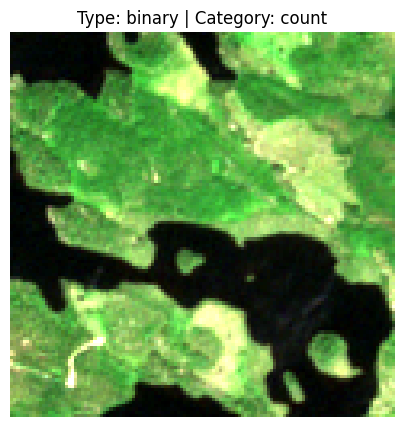

QUESTION: Are there at least two connected regions of mixed forests visible in the image?
ANSWER:   yes
Split:    train


In [10]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def get_patch_folder(patch_id, base="/content/usable_images/content/subset/images_s2/BigEarthNet-S2"):
    """Given a patch_id, find its full folder path."""
    for product_folder in os.listdir(base):
        candidate = os.path.join(base, product_folder, patch_id)
        if os.path.isdir(candidate):
            return candidate
    raise FileNotFoundError(f"No folder found for patch_id: {patch_id}")

def load_rgb(patch_folder):
    """Load B04 (Red), B03 (Green), B02 (Blue) and stack into a viewable RGB image."""
    bands = {}
    for b in ["B04", "B03", "B02"]:
        path = os.path.join(patch_folder, f"{os.path.basename(patch_folder)}_{b}.tif")
        with rasterio.open(path) as src:
            bands[b] = src.read(1).astype(np.float32)

    rgb = np.stack([bands["B04"], bands["B03"], bands["B02"]], axis=-1)

    # Normalize for display (Sentinel-2 reflectance values are typically 0-10000+)
    # Simple percentile stretch so the image isn't washed out or too dark
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb_stretched = np.clip((rgb - p2) / (p98 - p2), 0, 1)

    return rgb_stretched

# Test on our sample row
row = df.iloc[0]
patch_folder = get_patch_folder(row['patch_id'])
rgb_image = load_rgb(patch_folder)

plt.figure(figsize=(5,5))
plt.imshow(rgb_image)
plt.axis('off')
plt.title(f"Type: {row['type']} | Category: {row['category']}")
plt.show()

print("QUESTION:", row['input'])
print("ANSWER:  ", row['output'])
print("Split:   ", row['split'])

# Pre-render every unique patch to a PNG once (not per-row — some patches might be reused across multiple questions, so we don't want to redo the band-loading work multiple times)


In [11]:
import json
from pathlib import Path
from tqdm import tqdm

# ---- Step 1: Render every unique patch to PNG once ----

output_img_dir = "/content/processed_images"
os.makedirs(output_img_dir, exist_ok=True)

unique_patch_ids = df['patch_id'].unique()
print(f"Rendering {len(unique_patch_ids)} unique patches...")

patch_id_to_png = {}

for patch_id in tqdm(unique_patch_ids):
    png_path = os.path.join(output_img_dir, f"{patch_id}.png")

    if not os.path.exists(png_path):  # skip if already done (safe to re-run this cell)
        try:
            patch_folder = get_patch_folder(patch_id)
            rgb_image = load_rgb(patch_folder)
            plt.imsave(png_path, rgb_image)
        except Exception as e:
            print(f"FAILED on {patch_id}: {e}")
            continue

    patch_id_to_png[patch_id] = png_path

print(f"Done. {len(patch_id_to_png)} images rendered.")

Rendering 1847 unique patches...


100%|██████████| 1847/1847 [00:24<00:00, 74.78it/s]

Done. 1847 images rendered.


# Build the JSON chat file LLaMA-Factory expects, using the split column you already have

In [12]:
# ---- Step 2: Build the chat-format JSON, split by the existing 'split' column ----

def build_conversation(row):
    """Turn one dataframe row into LLaMA-Factory's sharegpt-with-images format."""
    return {
        "messages": [
            {
                "role": "user",
                "content": f"<image>{row['input']}"
            },
            {
                "role": "assistant",
                "content": str(row['output'])
            }
        ],
        "images": [patch_id_to_png[row['patch_id']]]
    }

splits = {"train": [], "val": [], "test": []}

for _, row in df.iterrows():
    if row['patch_id'] not in patch_id_to_png:
        continue  # skip any that failed to render

    entry = build_conversation(row)
    split_name = row['split'] if row['split'] in splits else "train"
    splits[split_name].append(entry)

for name, data in splits.items():
    out_path = f"/content/satquery_{name}.json"
    with open(out_path, "w") as f:
        json.dump(data, f, indent=2)
    print(f"{name}: {len(data)} examples -> {out_path}")

train: 1883 examples -> /content/satquery_train.json
val: 0 examples -> /content/satquery_val.json
test: 0 examples -> /content/satquery_test.json


In [13]:
from sklearn.model_selection import train_test_split

# Keep the original split for reference
df["original_split"] = df["split"]

# Get unique satellite patches
patch_ids = df["patch_id"].dropna().unique()

# 80% train, 20% temporary
train_ids, temp_ids = train_test_split(
    patch_ids,
    test_size=0.20,
    random_state=42
)

# Split remaining 20% equally into validation and test
val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42
)

train_ids = set(train_ids)
val_ids = set(val_ids)
test_ids = set(test_ids)

def assign_split(patch_id):
    if patch_id in train_ids:
        return "train"
    elif patch_id in val_ids:
        return "val"
    else:
        return "test"

df["split"] = df["patch_id"].apply(assign_split)

In [14]:
print(df['split'].value_counts())

split
train    1508
test      190
val       185
Name: count, dtype: int64


In [15]:
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    A = set(df[df["split"] == a]["patch_id"])
    B = set(df[df["split"] == b]["patch_id"])
    print(f"{a}-{b} overlap:", len(A & B))

train-val overlap: 0
train-test overlap: 0
val-test overlap: 0


In [16]:
# ---- Build final JSON files AFTER the patch-level split ----

def build_conversation(row):
    return {
        "messages": [
            {
                "role": "user",
                "content": f"<image>{row['input']}"
            },
            {
                "role": "assistant",
                "content": str(row['output'])
            }
        ],
        "images": [patch_id_to_png[row['patch_id']]]
    }

splits = {
    "train": [],
    "val": [],
    "test": []
}

for _, row in df.iterrows():

    if row['patch_id'] not in patch_id_to_png:
        continue

    entry = build_conversation(row)
    splits[row['split']].append(entry)

for name, data in splits.items():

    out_path = f"/content/satquery_{name}.json"

    with open(out_path, "w") as f:
        json.dump(data, f, indent=2)

    print(f"{name}: {len(data)} examples -> {out_path}")

train: 1508 examples -> /content/satquery_train.json
val: 185 examples -> /content/satquery_val.json
test: 190 examples -> /content/satquery_test.json


In [17]:
import os

sample_patch_id = df[df["split"] == "train"]["patch_id"].iloc[0]
sample_image = patch_id_to_png[sample_patch_id]

print("Patch ID:", sample_patch_id)
print("Image path:", sample_image)
print("Exists:", os.path.exists(sample_image))

Patch ID: S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84
Image path: /content/processed_images/S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84.png
Exists: True


Image size: (120, 120)
Image mode: RGBA


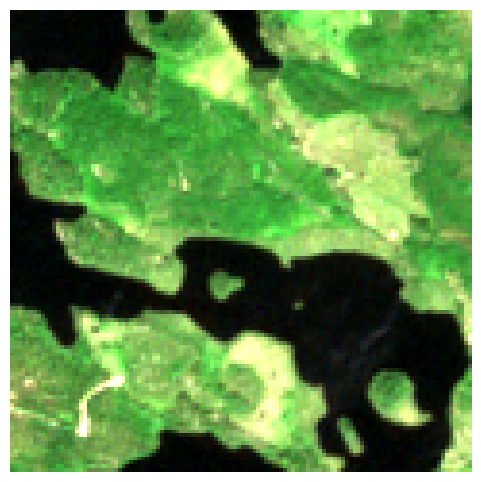

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(sample_image)

print("Image size:", img.size)
print("Image mode:", img.mode)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [19]:
!pip install -q git+https://github.com/huggingface/transformers
!pip install -q accelerate bitsandbytes qwen-vl-utils

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 20.5 MB/s eta 0:00:00


In [20]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [21]:
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

from qwen_vl_utils import process_vision_info

print("Qwen imports successful")

Qwen imports successful


In [22]:
MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("4-bit configuration ready")

4-bit configuration ready


In [23]:
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=quant_config,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=256 * 28 * 28,
    max_pixels=768 * 28 * 28
)

print("Qwen loaded successfully")

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/57.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Qwen loaded successfully


In [24]:
sample_row = df[df["split"] == "train"].iloc[0]

sample_patch_id = sample_row["patch_id"]
sample_image = patch_id_to_png[sample_patch_id]
sample_question = str(sample_row["input"])
sample_answer = str(sample_row["output"])

print("Patch ID:", sample_patch_id)
print("Image:", sample_image)
print("Question:", sample_question)
print("Ground truth:", sample_answer)

Patch ID: S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84
Image: /content/processed_images/S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_03_84.png
Question: Are there at least two connected regions of mixed forests visible in the image?
Ground truth: yes


In [25]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": sample_image,
            },
            {
                "type": "text",
                "text": sample_question,
            },
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)

inputs = {
    k: v.to(model.device) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

print("Qwen input prepared successfully")

Qwen input prepared successfully


In [26]:
with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=128
    )

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
]

output_text = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)

print("QUESTION:")
print(sample_question)

print("\nGROUND TRUTH:")
print(sample_answer)

print("\nQWEN ANSWER:")
print(output_text[0])

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (3420) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(


QUESTION:
Are there at least two connected regions of mixed forests visible in the image?

GROUND TRUTH:
yes

QWEN ANSWER:
Yes, there appear to be at least two connected regions of mixed forests visible in the image. The green areas represent forested regions, and they seem to be adjacent or connected to each other.


In [27]:
import json
import re
import torch
from tqdm.auto import tqdm

# Load validation data
with open("/content/satquery_val.json", "r") as f:
    val_data = json.load(f)

print("Validation examples:", len(val_data))

# Test only 20 samples first
N = min(20, len(val_data))
results = []

for i, sample in enumerate(tqdm(val_data[:N], desc="Running Qwen")):

    # Get image
    image_path = sample["images"][0]

    # Get question from the user message
    question = sample["messages"][0]["content"]

    # Remove the image placeholder if present
    question = question.replace("<image>", "").strip()

    # Ground truth
    ground_truth = sample["messages"][1]["content"].strip()

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path,
                },
                {
                    "type": "text",
                    "text": question,
                },
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=64
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]

    prediction = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip()

    results.append({
        "question": question,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "image": image_path
    })

    # Free temporary tensors
    del inputs, generated_ids, generated_ids_trimmed
    torch.cuda.empty_cache()

print("\nFinished.")
print("Results:", len(results))

Validation examples: 185


Running Qwen:   0%|          | 0/20 [00:00<?, ?it/s]


Finished.
Results: 20


In [28]:
for i, r in enumerate(results):
    print("=" * 80)
    print(f"Sample {i+1}")
    print("QUESTION :", r["question"])
    print("EXPECTED :", r["ground_truth"])
    print("QWEN     :", r["prediction"])

Sample 1
QUESTION : Does the image show four or more connected patches of permanent crops?
EXPECTED : no
QWEN     : The image shows multiple circular patches that appear to be agricultural fields, likely representing permanent crops such as orchards or vineyards. These patches are connected and form a pattern that suggests they are part of a larger agricultural area. Therefore, it can be inferred that there are four or more connected patches of permanent crops in the image
Sample 2
QUESTION : Do coniferous forests cover at least 70% of the image?
EXPECTED : no
QWEN     : The image appears to be a satellite view of a landscape, likely showing a mix of different types of vegetation and land use. Coniferous forests typically have a distinct appearance with dense, dark green canopies that are uniform in color and texture.

From the image provided, it is difficult to determine the exact percentage of con
Sample 3
QUESTION : Do marine waters appear in exactly four continuous areas in the ima

In [29]:
import json
import torch
from tqdm.auto import tqdm

# Load validation data
with open("/content/satquery_val.json", "r") as f:
    val_data = json.load(f)

# We will test only 20 samples first
N = min(20, len(val_data))

binary_results = []

for sample in tqdm(val_data[:N], desc="Qwen binary baseline"):

    image_path = sample["images"][0]

    question = sample["messages"][0]["content"]
    question = question.replace("<image>", "").strip()

    ground_truth = sample["messages"][1]["content"].strip().lower()

    # Force the task format
    prompt = f"""
Answer the following satellite-image question.

Question:
{question}

This is a YES/NO question.
Reply with exactly one word:
yes
or
no

Do not explain your answer.
"""

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]

    prediction = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip().lower()

    binary_results.append({
        "question": question,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "image": image_path
    })

    del inputs, generated_ids, generated_ids_trimmed
    torch.cuda.empty_cache()

print("\nFinished:", len(binary_results), "samples")

Qwen binary baseline:   0%|          | 0/20 [00:00<?, ?it/s]


Finished: 20 samples


In [30]:
for i, r in enumerate(binary_results):

    print("=" * 80)
    print(f"Sample {i + 1}")
    print("QUESTION :", r["question"])
    print("EXPECTED :", r["ground_truth"])
    print("QWEN     :", r["prediction"])

Sample 1
QUESTION : Does the image show four or more connected patches of permanent crops?
EXPECTED : no
QWEN     : yes
Sample 2
QUESTION : Do coniferous forests cover at least 70% of the image?
EXPECTED : no
QWEN     : no
Sample 3
QUESTION : Do marine waters appear in exactly four continuous areas in the image?
EXPECTED : no
QWEN     : no
Sample 4
QUESTION : Would you say that complex cultivation patterns take up between 10% and 20% of the image?
EXPECTED : no
QWEN     : no
Sample 5
QUESTION : Can you observe any coniferous forest in the satellite image?
EXPECTED : no
QWEN     : yes
Sample 6
QUESTION : Does any broad-leaved forest physically connect to transitional woodlands or shrubs in the image?
EXPECTED : no
QWEN     : no
Sample 7
QUESTION : Does this satellite image include transitional woodlands or shrubs?
EXPECTED : yes
QWEN     : yes
Sample 8
QUESTION : Do transitional woodlands or shrubs occupy less than three connected regions in the image?
EXPECTED : yes
QWEN     : no
Sampl

In [31]:
correct = 0

for r in binary_results:
    pred = r["prediction"].strip()
    truth = r["ground_truth"].strip()

    if pred == truth:
        correct += 1

accuracy = correct / len(binary_results)

print(f"Correct: {correct}/{len(binary_results)}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Correct: 11/20
Accuracy: 55.00%


In [32]:
# Run Qwen on the complete validation set

import json
import torch
from tqdm.auto import tqdm

with open("/content/satquery_val.json", "r") as f:
    val_data = json.load(f)

print("Validation samples:", len(val_data))

binary_results = []

for sample in tqdm(val_data, desc="Qwen validation"):

    image_path = sample["images"][0]

    question = sample["messages"][0]["content"]
    question = question.replace("<image>", "").strip()

    ground_truth = sample["messages"][1]["content"].strip().lower()

    prompt = f"""
Answer the following satellite-image question.

Question:
{question}

This is a YES/NO question.
Reply with exactly one word:
yes
or
no

Do not explain your answer.
"""

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]

    prediction = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip().lower()

    binary_results.append({
        "question": question,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "image": image_path
    })

    del inputs, generated_ids, generated_ids_trimmed
    torch.cuda.empty_cache()

print("\nFinished:", len(binary_results))

Validation samples: 185


Qwen validation:   0%|          | 0/185 [00:00<?, ?it/s]


Finished: 185


In [33]:
correct = 0

for r in binary_results:
    if r["prediction"].strip() == r["ground_truth"].strip():
        correct += 1

accuracy = correct / len(binary_results)

print(f"Correct: {correct}/{len(binary_results)}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Correct: 28/185
Accuracy: 15.14%


In [34]:
valid = 0
invalid = 0

for r in binary_results:
    pred = r["prediction"].strip()

    if pred in ["yes", "no"]:
        valid += 1
    else:
        invalid += 1

print("Valid yes/no:", valid)
print("Invalid:", invalid)

Valid yes/no: 185
Invalid: 0


In [35]:
from collections import Counter

truths = [r["ground_truth"] for r in binary_results]
preds = [r["prediction"] for r in binary_results]

print("Ground truth distribution:")
print(Counter(truths))

print("\nPrediction distribution:")
print(Counter(preds))

Ground truth distribution:
Counter({'no': 28, 'yes': 18, 'a': 15, 'c': 14, 'd': 14, 'b': 7, 'this satellite image, captured during the summer season in ireland, showcases a landscape entirely dominated by marine waters (~1,440,000 sqm), indicating a coastal or oceanic environment, set within the "temperate, no dry season, warm summer" climate zone.': 4, 'this satellite image, captured during the summer season in portugal, showcases a landscape entirely dominated by marine waters (~1,440,000 sqm), with no visible landmasses or other features, set within the "temperate, dry summer, hot summer" climate zone.': 2, 'this satellite image, captured during the fall season in serbia, showcases a landscape fully covered by arable land, spanning approximately 1,440,000 square meters, within the "temperate, no dry season, hot summer" climate zone.': 2, '[0.78 0.85, 1.0 1.0]': 1, '[0.0 0.43, 0.14 0.8]': 1, '[0.11 0.0, 0.86 0.45]': 1, '[0.38 0.0, 0.6 0.23]': 1, '[0.0 0.0, 0.94 0.75]': 1, '[0.0 0.23,

In [36]:
print(df["type"].value_counts())

type
mcq             499
binary          495
captioning      479
bounding box    410
Name: count, dtype: int64


In [37]:
# Select ONLY binary questions from validation set

binary_val_df = df[
    (df["split"] == "val") &
    (df["type"] == "binary")
].copy()

print("Binary validation samples:", len(binary_val_df))

print("\nLabel distribution:")
print(binary_val_df["output"].str.lower().value_counts())

Binary validation samples: 46

Label distribution:
output
no     28
yes    18
Name: count, dtype: int64


In [38]:
import torch
from tqdm.auto import tqdm

binary_results = []

for _, row in tqdm(
    binary_val_df.iterrows(),
    total=len(binary_val_df),
    desc="Qwen binary validation"
):

    patch_id = row["patch_id"]
    image_path = patch_id_to_png[patch_id]

    question = str(row["input"]).strip()
    ground_truth = str(row["output"]).strip().lower()

    prompt = f"""
Answer this satellite image question.

Question:
{question}

Answer with exactly one word:
yes
or
no

Do not provide an explanation.
"""

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]

    prediction = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip().lower()

    binary_results.append({
        "patch_id": patch_id,
        "question": question,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "image": image_path
    })

    del inputs, generated_ids, generated_ids_trimmed
    torch.cuda.empty_cache()

print("\nFinished:", len(binary_results))

Qwen binary validation:   0%|          | 0/46 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (3420) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(



Finished: 46


In [39]:
for i, r in enumerate(binary_results):

    print("=" * 80)
    print(f"Sample {i + 1}")
    print("QUESTION :", r["question"])
    print("EXPECTED :", r["ground_truth"])
    print("QWEN     :", r["prediction"])

Sample 1
QUESTION : Does the image show four or more connected patches of permanent crops?
EXPECTED : no
QWEN     : yes
Sample 2
QUESTION : Do coniferous forests cover at least 70% of the image?
EXPECTED : no
QWEN     : no
Sample 3
QUESTION : Do marine waters appear in exactly four continuous areas in the image?
EXPECTED : no
QWEN     : no
Sample 4
QUESTION : Would you say that complex cultivation patterns take up between 10% and 20% of the image?
EXPECTED : no
QWEN     : no
Sample 5
QUESTION : Can you observe any coniferous forest in the satellite image?
EXPECTED : no
QWEN     : yes
Sample 6
QUESTION : Does any broad-leaved forest physically connect to transitional woodlands or shrubs in the image?
EXPECTED : no
QWEN     : no
Sample 7
QUESTION : Does this satellite image include transitional woodlands or shrubs?
EXPECTED : yes
QWEN     : yes
Sample 8
QUESTION : Do transitional woodlands or shrubs occupy less than three connected regions in the image?
EXPECTED : yes
QWEN     : no
Sampl

In [40]:
valid_results = [
    r for r in binary_results
    if r["prediction"] in ["yes", "no"]
]

correct = sum(
    r["prediction"] == r["ground_truth"]
    for r in valid_results
)

accuracy = correct / len(valid_results)

print("Valid predictions:", len(valid_results))
print("Correct:", correct)
print("Accuracy:", f"{accuracy * 100:.2f}%")

Valid predictions: 46
Correct: 25
Accuracy: 54.35%


In [41]:
invalid = [
    r for r in binary_results
    if r["prediction"] not in ["yes", "no"]
]

print("Invalid predictions:", len(invalid))

Invalid predictions: 0


In [42]:
mcq_val_df = df[
    (df["split"] == "val") &
    (df["type"] == "mcq")
].copy()

print("MCQ validation samples:", len(mcq_val_df))

print("\nAnswer distribution:")
print(mcq_val_df["output"].value_counts())

MCQ validation samples: 50

Answer distribution:
output
a    15
c    14
d    14
b     7
Name: count, dtype: int64


In [43]:
import torch
from tqdm.auto import tqdm

mcq_results = []

for _, row in tqdm(
    mcq_val_df.iterrows(),
    total=len(mcq_val_df),
    desc="Qwen MCQ validation"
):

    image_path = patch_id_to_png[row["patch_id"]]

    question = str(row["input"]).strip()
    ground_truth = str(row["output"]).strip().lower()

    prompt = f"""
Answer the following multiple-choice question about the satellite image.

{question}

Reply with ONLY the letter of the correct answer:
a
b
c
or
d

Do not provide an explanation.
"""

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=3,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]

    prediction = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip().lower()

    mcq_results.append({
        "patch_id": row["patch_id"],
        "question": question,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "image": image_path
    })

    del inputs, generated_ids, generated_ids_trimmed
    torch.cuda.empty_cache()

print("\nFinished:", len(mcq_results))

Qwen MCQ validation:   0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (3420) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(



Finished: 50


In [44]:
for i, r in enumerate(mcq_results):
    print("=" * 80)
    print(f"Sample {i + 1}")
    print("QUESTION :", r["question"])
    print("EXPECTED :", r["ground_truth"])
    print("QWEN     :", r["prediction"])

Sample 1
QUESTION : Identify which pair is touching: a) Arable land and Mixed forest, b) Mixed forest and Pastures, c) Inland waters and Mixed forest, d) Marine waters and Transitional woodland, shrub
EXPECTED : c
QWEN     : c
Sample 2
QUESTION : Which classes are in contact in this scene? a) Arable land and Inland waters, b) Agro-forestry areas and Arable land, c) Pastures and Transitional woodland, shrub, d) Inland waters and Pastures
EXPECTED : b
QWEN     : c
Sample 3
QUESTION : In which season was the satellite image captured? a) Spring, b) Winter, c) Summer, d) Autumn
EXPECTED : c
QWEN     : d
Sample 4
QUESTION : Which country does the satellite image capture? a) Switzerland, b) Finland, c) Austria, d) Luxembourg
EXPECTED : c
QWEN     : b
Sample 5
QUESTION : From the options below, select the season shown in the satellite image: a) Fall, b) Autumn, c) Winter, d) Summer
EXPECTED : a
QWEN     : d
Sample 6
QUESTION : Select the classes that share a boundary: a) Land principally occup

In [45]:
import os

print("Files/folders in /content:\n")

for item in sorted(os.listdir("/content")):
    path = os.path.join("/content", item)

    if os.path.isdir(path):
        try:
            count = len(os.listdir(path))
        except:
            count = "?"
        print(f"[DIR]  {item}  ({count} items)")
    else:
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"[FILE] {item}  ({size_mb:.2f} MB)")

Files/folders in /content:

[DIR]  .config  (10 items)
[DIR]  processed_images  (1847 items)
[DIR]  sample_data  (6 items)
[FILE] satquery_test.json  (0.10 MB)
[FILE] satquery_train.json  (0.79 MB)
[FILE] satquery_val.json  (0.10 MB)
[DIR]  usable_images  (1 items)


In [46]:
import shutil
import os

if os.path.exists("/content/usable_images"):
    shutil.rmtree("/content/usable_images")
    print("Removed /content/usable_images")
else:
    print("Already removed")

Removed /content/usable_images


In [47]:
import os

for item in sorted(os.listdir("/content")):
    print(item)

.config
processed_images
sample_data
satquery_test.json
satquery_train.json
satquery_val.json


In [48]:
for i, r in enumerate(mcq_results):
    print("=" * 80)
    print(f"Sample {i + 1}")
    print("QUESTION :", r["question"])
    print("EXPECTED :", r["ground_truth"])
    print("QWEN     :", r["prediction"])

Sample 1
QUESTION : Identify which pair is touching: a) Arable land and Mixed forest, b) Mixed forest and Pastures, c) Inland waters and Mixed forest, d) Marine waters and Transitional woodland, shrub
EXPECTED : c
QWEN     : c
Sample 2
QUESTION : Which classes are in contact in this scene? a) Arable land and Inland waters, b) Agro-forestry areas and Arable land, c) Pastures and Transitional woodland, shrub, d) Inland waters and Pastures
EXPECTED : b
QWEN     : c
Sample 3
QUESTION : In which season was the satellite image captured? a) Spring, b) Winter, c) Summer, d) Autumn
EXPECTED : c
QWEN     : d
Sample 4
QUESTION : Which country does the satellite image capture? a) Switzerland, b) Finland, c) Austria, d) Luxembourg
EXPECTED : c
QWEN     : b
Sample 5
QUESTION : From the options below, select the season shown in the satellite image: a) Fall, b) Autumn, c) Winter, d) Summer
EXPECTED : a
QWEN     : d
Sample 6
QUESTION : Select the classes that share a boundary: a) Land principally occup

In [49]:
valid_mcq = [
    r for r in mcq_results
    if r["prediction"] in ["a", "b", "c", "d"]
]

correct_mcq = sum(
    r["prediction"] == r["ground_truth"]
    for r in valid_mcq
)

accuracy_mcq = correct_mcq / len(valid_mcq)

print("Valid predictions:", len(valid_mcq))
print("Correct:", correct_mcq)
print("MCQ Accuracy:", f"{accuracy_mcq * 100:.2f}%")

invalid_mcq = len(mcq_results) - len(valid_mcq)
print("Invalid predictions:", invalid_mcq)

Valid predictions: 50
Correct: 18
MCQ Accuracy: 36.00%
Invalid predictions: 0


In [50]:
from collections import Counter

print("Ground truth:")
print(Counter(r["ground_truth"] for r in mcq_results))

print("\nQwen predictions:")
print(Counter(r["prediction"] for r in mcq_results))

Ground truth:
Counter({'a': 15, 'c': 14, 'd': 14, 'b': 7})

Qwen predictions:
Counter({'c': 18, 'd': 14, 'b': 12, 'a': 6})


In [51]:
caption_val_df = df[
    (df["split"] == "val") &
    (df["type"] == "captioning")
].copy()

print("Caption validation samples:", len(caption_val_df))

print("\nExample captions:\n")

for i, (_, row) in enumerate(caption_val_df.head(5).iterrows()):
    print("=" * 80)
    print("QUESTION:", row["input"])
    print("REFERENCE:", row["output"])

Caption validation samples: 49

Example captions:

QUESTION: Provide a summary of the scene, including geographic information, season, and land cover classes.
REFERENCE: This satellite image, captured during the fall season in Serbia, showcases a diverse landscape within the "temperate, no dry season, hot summer" climate zone. The dominant features are broad-leaved forest (~615,000 sqm) and complex cultivation patterns (~585,000 sqm), which are adjacent to each other. The expansive broad-leaved forest also borders a smaller mixed forest (~143,000 sqm). Furthermore, the complex cultivation patterns are next to both the mixed forest and arable land (~97,000 sqm), indicating a mosaic of agricultural and forested areas. The broad-leaved forest is also adjacent to arable land is not mentioned but  broad-leaved forest borders complex cultivation patterns and mixed forest and complex cultivation patterns is adjacent to mixed forest and arable land. The varied landscape suggests a dynamic ecos

In [52]:
import torch
from tqdm.auto import tqdm

caption_results = []

for _, row in tqdm(
    caption_val_df.iterrows(),
    total=len(caption_val_df),
    desc="Qwen captioning validation"
):

    image_path = patch_id_to_png[row["patch_id"]]
    question = str(row["input"]).strip()
    reference = str(row["output"]).strip()

    prompt = f"""
Look at the satellite image and answer the following request.

{question}

Provide a concise factual description based only on what can be inferred from the image.
Do not mention that you are an AI.
"""

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]

    prediction = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip()

    caption_results.append({
        "patch_id": row["patch_id"],
        "question": question,
        "reference": reference,
        "prediction": prediction,
        "image": image_path
    })

    del inputs, generated_ids, generated_ids_trimmed
    torch.cuda.empty_cache()

print("\nFinished:", len(caption_results))

Qwen captioning validation:   0%|          | 0/49 [00:00<?, ?it/s]


Finished: 49


In [53]:
for i, r in enumerate(caption_results[:10]):
    print("=" * 100)
    print(f"Sample {i + 1}")
    print("QUESTION :")
    print(r["question"])
    print("\nREFERENCE:")
    print(r["reference"])
    print("\nQWEN:")
    print(r["prediction"])

Sample 1
QUESTION :
Provide a summary of the scene, including geographic information, season, and land cover classes.

REFERENCE:
This satellite image, captured during the fall season in Serbia, showcases a diverse landscape within the "temperate, no dry season, hot summer" climate zone. The dominant features are broad-leaved forest (~615,000 sqm) and complex cultivation patterns (~585,000 sqm), which are adjacent to each other. The expansive broad-leaved forest also borders a smaller mixed forest (~143,000 sqm). Furthermore, the complex cultivation patterns are next to both the mixed forest and arable land (~97,000 sqm), indicating a mosaic of agricultural and forested areas. The broad-leaved forest is also adjacent to arable land is not mentioned but  broad-leaved forest borders complex cultivation patterns and mixed forest and complex cultivation patterns is adjacent to mixed forest and arable land. The varied landscape suggests a dynamic ecosystem, with a mix of forest and agricult

In [54]:
!pip install -q nltk rouge-score

In [56]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import numpy as np

# Download both tokenizer resources
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

smooth = SmoothingFunction().method1

rouge = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

bleu_scores = []
rouge_scores = []

for r in caption_results:

    reference = r["reference"].lower().strip()
    prediction = r["prediction"].lower().strip()

    reference_tokens = nltk.word_tokenize(reference)
    prediction_tokens = nltk.word_tokenize(prediction)

    if not prediction_tokens:
        continue

    # BLEU-4
    bleu = sentence_bleu(
        [reference_tokens],
        prediction_tokens,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    # ROUGE-L
    rouge_l = rouge.score(
        reference,
        prediction
    )["rougeL"].fmeasure

    bleu_scores.append(bleu)
    rouge_scores.append(rouge_l)

print("Captioning validation samples:", len(caption_results))
print("Average BLEU-4:", f"{np.mean(bleu_scores):.4f}")
print("Average ROUGE-L:", f"{np.mean(rouge_scores):.4f}")

Captioning validation samples: 49
Average BLEU-4: 0.0155
Average ROUGE-L: 0.1580


In [57]:
bbox_val_df = df[
    (df["split"] == "val") &
    (df["type"] == "bounding box")
].copy()

print("Bounding-box validation samples:", len(bbox_val_df))

print("\nExample bounding-box samples:\n")

for i, (_, row) in enumerate(bbox_val_df.head(5).iterrows()):
    print("=" * 80)
    print("QUESTION:")
    print(row["input"])
    print("\nREFERENCE:")
    print(row["output"])

Bounding-box validation samples: 40

Example bounding-box samples:

QUESTION:
Show a continuous region of <ref>agro-forestry areas</ref> in the scene.

REFERENCE:
[0.78 0.85, 1.0 1.0]
QUESTION:
Create a bounding box for the land cover class instance positioned at <point>(0.06, 0.63)</point> in the image.

REFERENCE:
[0.0 0.43, 0.14 0.8]
QUESTION:
Where can the <ref>largest continuous region of permanent crops</ref> be found?

REFERENCE:
[0.11 0.0, 0.86 0.45]
QUESTION:
Provide a bounding box surrounding the land cover class instance positioned at <point>(0.51, 0.1)</point> in the image.

REFERENCE:
[0.38 0.0, 0.6 0.23]
QUESTION:
Output a bounding box surrounding the land cover class instance at <point>(0.46, 0.37)</point> in the satellite image.

REFERENCE:
[0.0 0.0, 0.94 0.75]


In [58]:
import torch
import re
from tqdm.auto import tqdm

bbox_results = []

for _, row in tqdm(
    bbox_val_df.iterrows(),
    total=len(bbox_val_df),
    desc="Qwen bounding-box validation"
):

    image_path = patch_id_to_png[row["patch_id"]]
    question = str(row["input"]).strip()
    reference = str(row["output"]).strip()

    prompt = f"""
Look at the satellite image and answer the following bounding-box request.

{question}

Return ONLY the bounding box coordinates in this exact format:

[x1 y1, x2 y2]

All coordinates must be normalized between 0 and 1.
Do not provide any explanation or additional text.
"""

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=32,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]

    prediction = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip()

    bbox_results.append({
        "patch_id": row["patch_id"],
        "question": question,
        "ground_truth": reference,
        "prediction": prediction,
        "image": image_path
    })

    del inputs, generated_ids, generated_ids_trimmed
    torch.cuda.empty_cache()

print("\nFinished:", len(bbox_results))

Qwen bounding-box validation:   0%|          | 0/40 [00:00<?, ?it/s]


Finished: 40


In [59]:
def parse_bbox(text):
    """
    Extract first four numeric values from a bounding-box string.
    Expected format:
    [x1 y1, x2 y2]
    """

    numbers = re.findall(
        r"[-+]?(?:\d*\.\d+|\d+\.?\d*)",
        str(text)
    )

    if len(numbers) < 4:
        return None

    coords = [float(x) for x in numbers[:4]]

    # Clamp normalized coordinates
    coords = [
        max(0.0, min(1.0, x))
        for x in coords
    ]

    x1, y1, x2, y2 = coords

    # Ensure proper ordering
    x1, x2 = min(x1, x2), max(x1, x2)
    y1, y2 = min(y1, y2), max(y1, y2)

    return [x1, y1, x2, y2]


for r in bbox_results:
    r["gt_bbox"] = parse_bbox(r["ground_truth"])
    r["pred_bbox"] = parse_bbox(r["prediction"])

print("Total:", len(bbox_results))
print(
    "Valid predictions:",
    sum(r["pred_bbox"] is not None for r in bbox_results)
)
print(
    "Invalid predictions:",
    sum(r["pred_bbox"] is None for r in bbox_results)
)

Total: 40
Valid predictions: 29
Invalid predictions: 11


In [60]:
def calculate_iou(box1, box2):

    if box1 is None or box2 is None:
        return 0.0

    x1, y1, x2, y2 = box1
    a1, b1, a2, b2 = box2

    # Intersection
    ix1 = max(x1, a1)
    iy1 = max(y1, b1)
    ix2 = min(x2, a2)
    iy2 = min(y2, b2)

    intersection_width = max(0.0, ix2 - ix1)
    intersection_height = max(0.0, iy2 - iy1)

    intersection = (
        intersection_width *
        intersection_height
    )

    # Areas
    area1 = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area2 = max(0.0, a2 - a1) * max(0.0, b2 - b1)

    union = area1 + area2 - intersection

    if union <= 0:
        return 0.0

    return intersection / union


ious = []

for r in bbox_results:

    iou = calculate_iou(
        r["gt_bbox"],
        r["pred_bbox"]
    )

    r["iou"] = iou
    ious.append(iou)


import numpy as np

print("Bounding-box samples:", len(bbox_results))
print("Mean IoU:", f"{np.mean(ious):.4f}")
print("Median IoU:", f"{np.median(ious):.4f}")
print("IoU >= 0.50:", f"{np.mean(np.array(ious) >= 0.50) * 100:.2f}%")
print("IoU >= 0.75:", f"{np.mean(np.array(ious) >= 0.75) * 100:.2f}%")

Bounding-box samples: 40
Mean IoU: 0.1100
Median IoU: 0.0000
IoU >= 0.50: 7.50%
IoU >= 0.75: 0.00%


In [61]:
for i, r in enumerate(bbox_results[:10]):

    print("=" * 90)
    print(f"Sample {i + 1}")

    print("QUESTION:")
    print(r["question"])

    print("\nGROUND TRUTH:")
    print(r["ground_truth"])

    print("\nQWEN:")
    print(r["prediction"])

    print("\nGT PARSED:")
    print(r["gt_bbox"])

    print("PRED PARSED:")
    print(r["pred_bbox"])

    print("IoU:", f"{r['iou']:.4f}")

Sample 1
QUESTION:
Show a continuous region of <ref>agro-forestry areas</ref> in the scene.

GROUND TRUTH:
[0.78 0.85, 1.0 1.0]

QWEN:
[0, 0, 476, 476]

GT PARSED:
[0.78, 0.85, 1.0, 1.0]
PRED PARSED:
[0.0, 0.0, 1.0, 1.0]
IoU: 0.0330
Sample 2
QUESTION:
Create a bounding box for the land cover class instance positioned at <point>(0.06, 0.63)</point> in the image.

GROUND TRUTH:
[0.0 0.43, 0.14 0.8]

QWEN:
[0.06, 0.63]

GT PARSED:
[0.0, 0.43, 0.14, 0.8]
PRED PARSED:
None
IoU: 0.0000
Sample 3
QUESTION:
Where can the <ref>largest continuous region of permanent crops</ref> be found?

GROUND TRUTH:
[0.11 0.0, 0.86 0.45]

QWEN:
[345,228,476,390]

GT PARSED:
[0.11, 0.0, 0.86, 0.45]
PRED PARSED:
[1.0, 1.0, 1.0, 1.0]
IoU: 0.0000
Sample 4
QUESTION:
Provide a bounding box surrounding the land cover class instance positioned at <point>(0.51, 0.1)</point> in the image.

GROUND TRUTH:
[0.38 0.0, 0.6 0.23]

QWEN:
[0.48, 0.07, 0.63, 0.2]

GT PARSED:
[0.38, 0.0, 0.6, 0.23]
PRED PARSED:
[0.48, 0.07, 0.63,

In [62]:
import torch
import re
from tqdm.auto import tqdm

bbox_results = []

for _, row in tqdm(
    bbox_val_df.iterrows(),
    total=len(bbox_val_df),
    desc="Qwen bounding-box validation"
):

    image_path = patch_id_to_png[row["patch_id"]]
    question = str(row["input"]).strip()
    reference = str(row["output"]).strip()

    prompt = f"""
Look at the satellite image and answer the following bounding-box request.

{question}

Return ONLY the bounding box coordinates in this exact format:

[x1 y1, x2 y2]

All coordinates must be normalized between 0 and 1.
Do not provide any explanation or additional text.
"""

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": prompt}
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=32,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]

    prediction = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip()

    bbox_results.append({
        "patch_id": row["patch_id"],
        "question": question,
        "ground_truth": reference,
        "prediction": prediction,
        "image": image_path
    })

    del inputs, generated_ids, generated_ids_trimmed
    torch.cuda.empty_cache()

print("\nFinished:", len(bbox_results))

Qwen bounding-box validation:   0%|          | 0/40 [00:00<?, ?it/s]


Finished: 40


In [63]:
def parse_bbox(text):

    numbers = re.findall(
        r"[-+]?(?:\d*\.\d+|\d+\.?\d*)",
        str(text)
    )

    if len(numbers) < 4:
        return None

    coords = [float(x) for x in numbers[:4]]

    coords = [
        max(0.0, min(1.0, x))
        for x in coords
    ]

    x1, y1, x2, y2 = coords

    x1, x2 = min(x1, x2), max(x1, x2)
    y1, y2 = min(y1, y2), max(y1, y2)

    return [x1, y1, x2, y2]


for r in bbox_results:
    r["gt_bbox"] = parse_bbox(r["ground_truth"])
    r["pred_bbox"] = parse_bbox(r["prediction"])

print("Total:", len(bbox_results))
print(
    "Valid predictions:",
    sum(r["pred_bbox"] is not None for r in bbox_results)
)
print(
    "Invalid predictions:",
    sum(r["pred_bbox"] is None for r in bbox_results)
)

Total: 40
Valid predictions: 29
Invalid predictions: 11


In [64]:
def calculate_iou(box1, box2):

    if box1 is None or box2 is None:
        return 0.0

    x1, y1, x2, y2 = box1
    a1, b1, a2, b2 = box2

    ix1 = max(x1, a1)
    iy1 = max(y1, b1)
    ix2 = min(x2, a2)
    iy2 = min(y2, b2)

    intersection = (
        max(0.0, ix2 - ix1) *
        max(0.0, iy2 - iy1)
    )

    area1 = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area2 = max(0.0, a2 - a1) * max(0.0, b2 - b1)

    union = area1 + area2 - intersection

    if union <= 0:
        return 0.0

    return intersection / union


import numpy as np

ious = []

for r in bbox_results:

    iou = calculate_iou(
        r["gt_bbox"],
        r["pred_bbox"]
    )

    r["iou"] = iou
    ious.append(iou)

print("Bounding-box samples:", len(bbox_results))
print("Mean IoU:", f"{np.mean(ious):.4f}")
print("Median IoU:", f"{np.median(ious):.4f}")
print(
    "IoU >= 0.50:",
    f"{np.mean(np.array(ious) >= 0.50) * 100:.2f}%"
)
print(
    "IoU >= 0.75:",
    f"{np.mean(np.array(ious) >= 0.75) * 100:.2f}%"
)

Bounding-box samples: 40
Mean IoU: 0.1100
Median IoU: 0.0000
IoU >= 0.50: 7.50%
IoU >= 0.75: 0.00%


In [65]:
for i, r in enumerate(bbox_results[:10]):

    print("=" * 90)
    print(f"Sample {i + 1}")

    print("QUESTION:")
    print(r["question"])

    print("\nGROUND TRUTH:")
    print(r["ground_truth"])

    print("\nQWEN:")
    print(r["prediction"])

    print("\nGT PARSED:")
    print(r["gt_bbox"])

    print("PRED PARSED:")
    print(r["pred_bbox"])

    print("IoU:", f"{r['iou']:.4f}")

Sample 1
QUESTION:
Show a continuous region of <ref>agro-forestry areas</ref> in the scene.

GROUND TRUTH:
[0.78 0.85, 1.0 1.0]

QWEN:
[0, 0, 476, 476]

GT PARSED:
[0.78, 0.85, 1.0, 1.0]
PRED PARSED:
[0.0, 0.0, 1.0, 1.0]
IoU: 0.0330
Sample 2
QUESTION:
Create a bounding box for the land cover class instance positioned at <point>(0.06, 0.63)</point> in the image.

GROUND TRUTH:
[0.0 0.43, 0.14 0.8]

QWEN:
[0.06, 0.63]

GT PARSED:
[0.0, 0.43, 0.14, 0.8]
PRED PARSED:
None
IoU: 0.0000
Sample 3
QUESTION:
Where can the <ref>largest continuous region of permanent crops</ref> be found?

GROUND TRUTH:
[0.11 0.0, 0.86 0.45]

QWEN:
[345,228,476,390]

GT PARSED:
[0.11, 0.0, 0.86, 0.45]
PRED PARSED:
[1.0, 1.0, 1.0, 1.0]
IoU: 0.0000
Sample 4
QUESTION:
Provide a bounding box surrounding the land cover class instance positioned at <point>(0.51, 0.1)</point> in the image.

GROUND TRUTH:
[0.38 0.0, 0.6 0.23]

QWEN:
[0.48, 0.07, 0.63, 0.2]

GT PARSED:
[0.38, 0.0, 0.6, 0.23]
PRED PARSED:
[0.48, 0.07, 0.63,

In [68]:
from PIL import Image
import os

for r in bbox_results[:10]:

    img = Image.open(r["image"])

    print("=" * 70)
    print("Image:", os.path.basename(r["image"]))
    print("Image size:", img.size)
    print("Qwen output:", r["prediction"])

In [69]:
import torch
import re
from tqdm.auto import tqdm

bbox_results = []

In [70]:
print("\nFinished:", len(bbox_results))


Finished: 0
